In [13]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

import gc
import sys
import os
from pathlib import Path

import xgboost as xgb
import matplotlib.pyplot as plt

#Indicamos el workspace principal (dos niveles atrás)
sys.path.append(os.path.abspath('../../'))

from src.utils_pisa import *


%load_ext autoreload
%autoreload 2


establecer_semilla(42)
pd.set_option('display.float_format', lambda valor: f'{valor:.2f}')

ruta_modelos = Path('../../data/models')
ruta_datos_llm = Path('../../agente_llm/data_llm')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Semillas del proyecto establecidas con éxito (seed=42).


In [10]:
#Cargamos el modelo 

modelo_math = joblib.load(ruta_modelos/'modelo_xgb_math_opt.pkl')
X_test = joblib.load(ruta_modelos/'X_test_preparado.pkl')

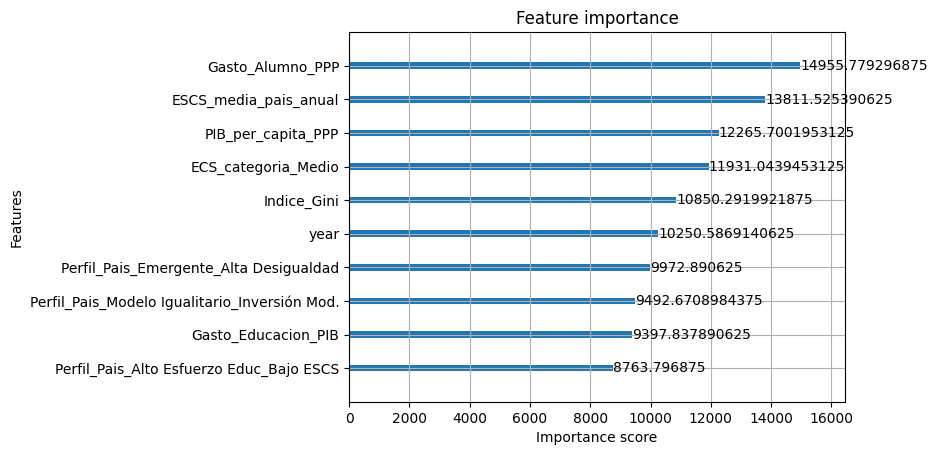

In [5]:
# Ver los valores numéricos directos
importancias = modelo_math.feature_importances_

# Graficar la importancia nativa de XGBoost
xgb.plot_importance(modelo_math, importance_type='gain', max_num_features=10)
plt.show()

In [12]:
# SHAP
explainer = shap.TreeExplainer(modelo_math)
shap_values = explainer.shap_values(X_test)



In [14]:
joblib.dump(explainer,ruta_datos_llm/'shap_explainer.pkl')

['..\\..\\agente_llm\\data_llm\\shap_explainer.pkl']

C:\Users\victo\AppData\Local\Temp\ipykernel_17020\2940161786.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


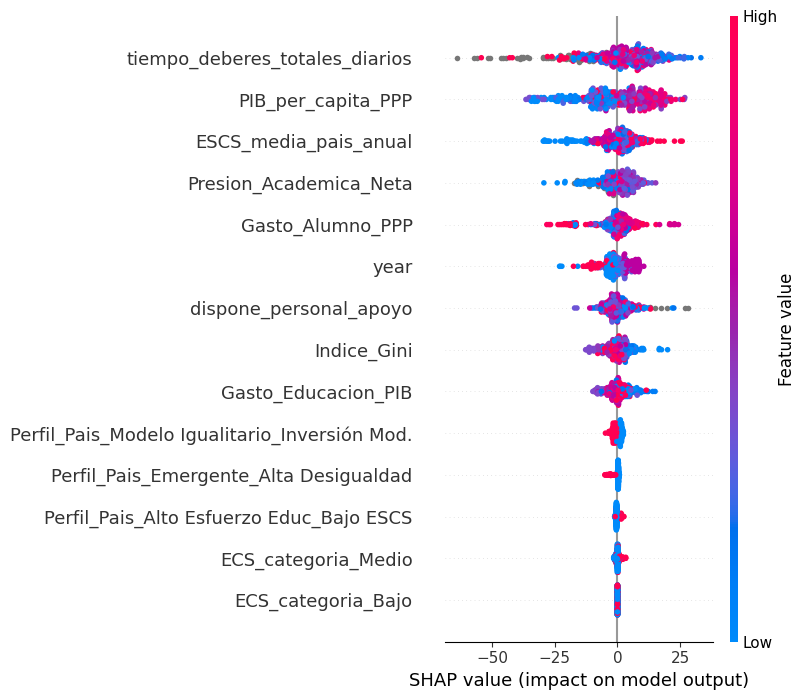

In [11]:
shap.summary_plot(shap_values, X_test)

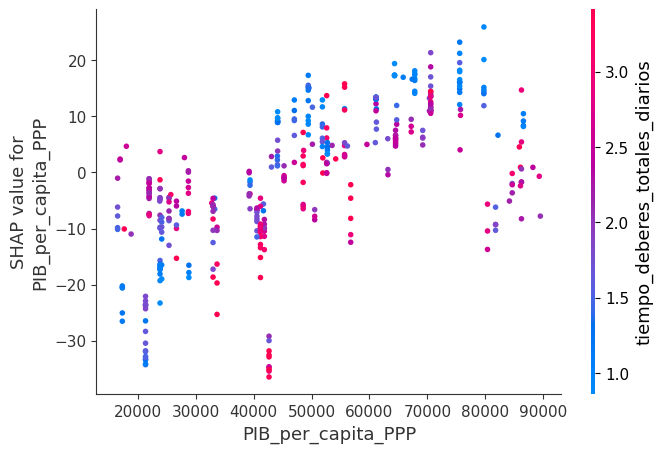

In [8]:
shap.dependence_plot(
    "PIB_per_capita_PPP", # Variable a analizar en el eje X
    shap_values, 
    X_test, 
    interaction_index="tiempo_deberes_totales_diarios" # Variable para colorear
)

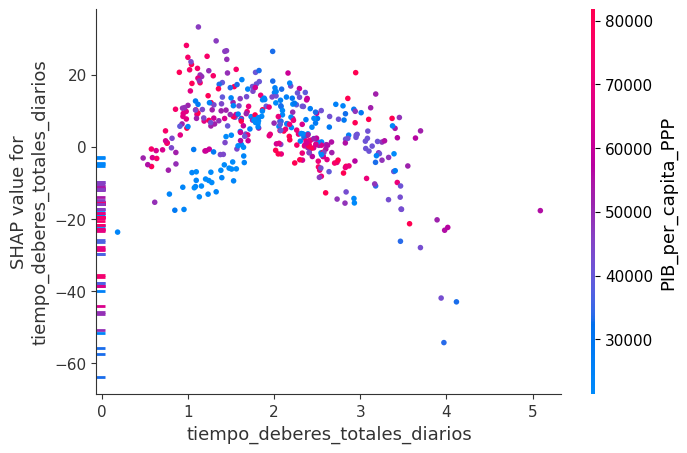

In [9]:
shap.dependence_plot(
    "tiempo_deberes_totales_diarios", # Variable a analizar en el eje X
    shap_values, 
    X_test, 
    interaction_index="PIB_per_capita_PPP" # Variable para colorear
)